In [1]:
from calc_setup import *
set_design_code('ec2_2004')


Calc environment ready.


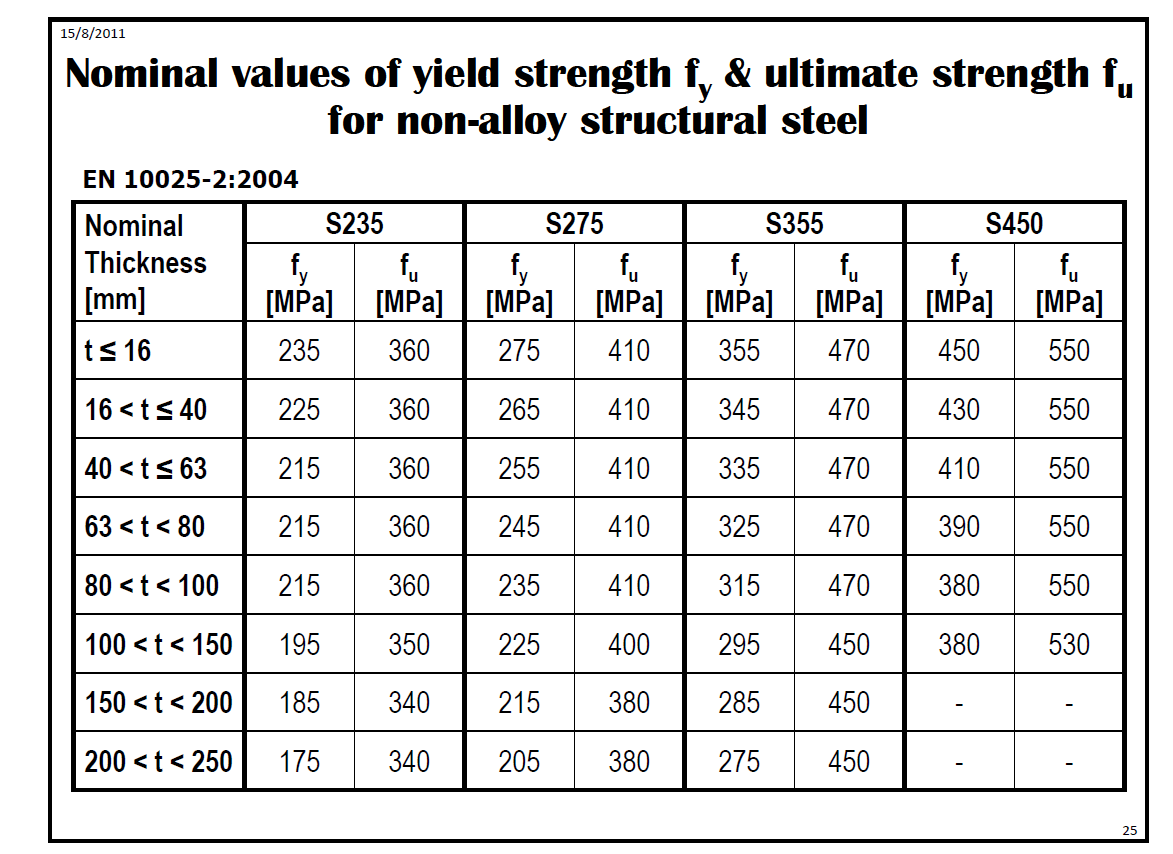


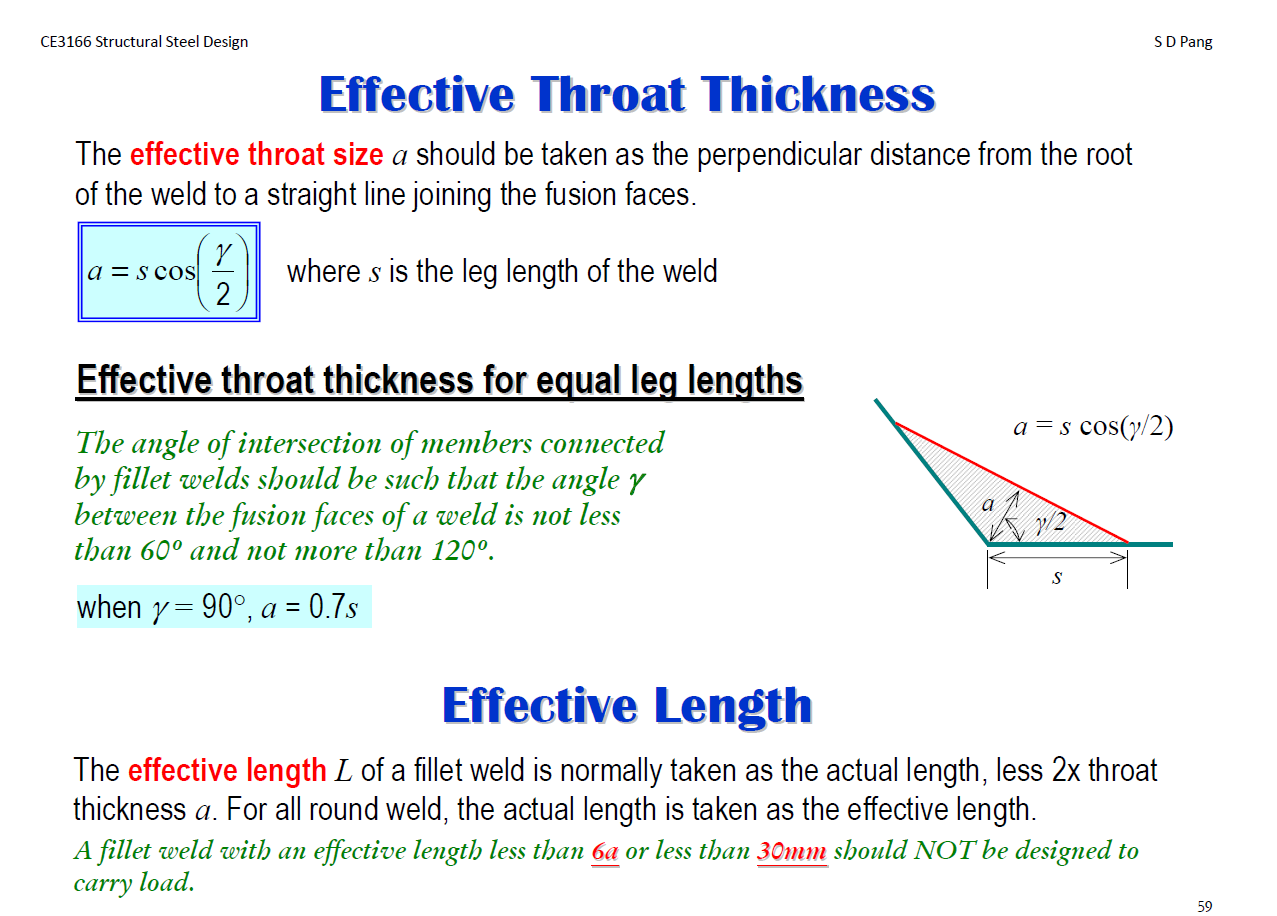

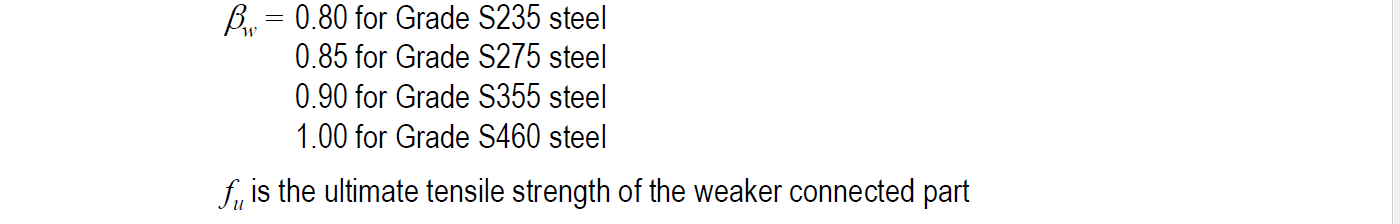

In [47]:
%%render

# -------------------------
# INPUTS (EDIT)
# -------------------------
fu = 430.0          # MPa, ultimate tensile strength (weaker of parts / weld metal per your assumption)
beta_w = 0.85        # correlation factor (confirm per NA/material)
gamma_M2 = 1.25     # partial factor for joints

s = 7.2            # mm, weld leg size
a = 0.7 * s         # mm effective throat thickness 70perc of leg size
l_eff = 90+2*50       # mm, effective weld length
n_lines = 1         # number of identical weld lines sharing load




<IPython.core.display.Latex object>

## Simple Method Weld Check

### Input

In [ ]:
%%render long
# -------------------------
# Loading
# -------------------------
V_Ed = 220        # KN, shear force to be resisted by weld

In [ ]:


# -------------------------
# EC3 DESIGN STRENGTH
# -------------------------
f_vw_d = fu / (sqrt(3) * beta_w * gamma_M2)     #  KN/mm2
# Throat area
A_w = n_lines * a * l_eff                        # mm2
# -------------------------
# 1) SIMPLE FILLET WELD (PURE SHEAR)
# EC3 directional method reduces to: sigma_eq = sqrt(3)*tau <= f_vw_d
# -------------------------
tau_simple = V_Ed*10**3 / A_w                          # MPa
util_simple = tau_simple / f_vw_d           # <=1 ok


<IPython.core.display.Latex object>

## Directional Method (GENERAL)

### Input

In [ ]:
%%render long
# -------------------------
# Loading
# -------------------------
V_Ed = 220        # KN, shear force to be resisted by weld

In [ ]:
%%render

# 1) DIRECTIONAL (GENERAL) CASE: force components w.r.t. weld axis
Fx_Ed = 10    # KN, parallel to weld axis (longitudinal shear component)
Fy_Ed = 25    # KN, transverse in-plane (transverse shear component)
Fz_Ed = 0.0         # KN, perpendicular to plate (normal component on throat)

# -------------------------
# 2) DIRECTIONAL METHOD (GENERAL)
# sigma_eq = sqrt( sigma_perp^2 + 3*(tau_perp^2 + tau_par^2) ) <= f_vw_d
# -------------------------

sigma_perp = Fz_Ed / A_w                          # MPa
tau_perp   = Fy_Ed / A_w                          # MPa
tau_par    = Fx_Ed / A_w                          # MPa

sigma_eq_dir = sqrt(sigma_perp**2 + 3*(tau_perp**2 + tau_par**2))  # MPa
util_dir = sigma_eq_dir / f_vw_d                   # -
ok_dir = util_dir <= 1.0                           # True/False


<IPython.core.display.Latex object>